In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        pass
       # print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import cv2
from PIL import Image
import tensorflow as ft
import glob

In [2]:
benign ='/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign'
malignant='/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/malignant'
normal='/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/normal'

In [3]:
count_benign=len(os.listdir(benign))
count_malignant=len(os.listdir(malignant))
count_normal=len(os.listdir(normal))

In [4]:
# Get the list of all the images
bening_cases = glob.glob(benign+ '/*')
malignant_cases =glob.glob(malignant+ '/*')
normal_cases = glob.glob(normal+ '/*')

# An empty list. We will insert the data into this list in (img_path, label) format
exclude=[]
train_data_mask = []
train_data_img=[]
# Go through all the normal cases. The label for these cases will be 0
for img in normal_cases:
    if img.endswith('_mask.png'):  
        train_data_mask.append(img)
    elif img.endswith('_mask_1.png') or img.endswith('_mask_2.png'):
        exclude.append(img)
    else :
        train_data_img.append(img) 

# Go through all the bening cases. The label for these cases will be 1
for img in bening_cases:
    if img.endswith('_mask.png'):
        train_data_mask.append(img)
    elif img.endswith('_mask_1.png') or img.endswith('_mask_2.png'):
        exclude.append(img)
    else:
        train_data_img.append(img)

# Go through all the malignant cases. The label for these cases will be 1
for img in malignant_cases:

    if img.endswith('_mask.png'):
        train_data_mask.append(img)
    elif img.endswith('_mask_1.png') or img.endswith('_mask_2.png'):
        exclude.append(img)
    else:
        train_data_img.append(img)


In [5]:
train_data_img = sorted(train_data_img)
train_data_mask = sorted(train_data_mask)

In [6]:
len(train_data_img), len(train_data_mask), len(exclude)

(780, 780, 18)

In [7]:
train_data_img[100]

'/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (19).png'

In [8]:
train_data_mask[100]

'/kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (19)_mask.png'

In [9]:
images=[]
masks=[]
size_x=128
size_y=128

for every_img_path in train_data_img:
    img=cv2.imread(every_img_path,cv2.IMREAD_COLOR)
    img=cv2.resize(img,(size_y, size_x))
    images.append(img)

for every_mask_path in train_data_mask:
    mask=cv2.imread(every_mask_path,0)
    mask=cv2.resize(mask,(size_y,size_x))
    masks.append(mask)
    
images = np.array(images)
masks = np.array(masks)

In [10]:
x=images/255
y=masks/255

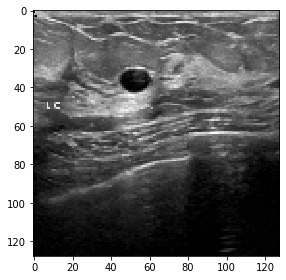

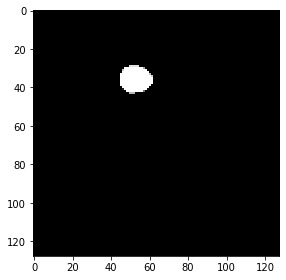

0.0 1.0
(128, 128, 3)
0.0 1.0
(128, 128)


In [11]:
import random
from skimage.io import imshow

########## Displaying random image from X_train and Y_train ######### 
random_num = random.randint(0,516)
imshow(x[random_num])
plt.show()
imshow(y[random_num])
plt.show() 

test_img = x[random_num]
test_img2 = y[random_num]
print(test_img.min(), test_img.max())
print(test_img.shape)

print(test_img2.min(), test_img2.max())
print(test_img2.shape)

In [27]:
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_val.shape)
print(x_val[20].shape)

(624, 128, 128, 3)
(156, 128, 128, 3)
(128, 128, 3)


In [13]:
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda
from keras.models import Model

IMG_WIDTH = 128
IMG_HEIGHT = 128
IMG_CHANNELS = 3

def simple_unet_model(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS):
    inputs = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    #s = Lambda(lambda x: x / 255)(inputs)   #No need for this if we normalize our inputs beforehand
    s = inputs

    #Contraction path
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(s)
    c1 = Dropout(0.1)(c1)
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = Dropout(0.1)(c2)
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)
     
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)
     
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = MaxPooling2D(pool_size=(2, 2))(c4)
     
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)
    
    #Expansive path 
    u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
     
    u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
     
    u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)
     
    u9 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1], axis=3)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)
     
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)
     
    model = Model(inputs=[inputs], outputs=[outputs])
    # model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    # model.summary()
    
    return model

In [14]:
def get_model():
    return simple_unet_model(IMG_HEIGHT,IMG_WIDTH,IMG_CHANNELS)

In [15]:
model = get_model()
model.summary()

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 128, 128, 3) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 128, 128, 16) 448         input_1[0][0]                    
__________________________________________________________________________________________________
dropout (Dropout)               (None, 128, 128, 16) 0           conv2d[0][0]                     
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 128, 128, 16) 2320        dropout[0][0]                    
______________________________________________________________________________________________

In [19]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['mse','accuracy'])

In [20]:
history=model.fit(x_train,
          y_train,
          batch_size=20, 
          epochs=50,
          verbose=1,
          validation_data=(x_val, y_val))

Epoch 1/50
32/32 [==============================] - 4s 59ms/step - loss: 0.1242 - mse: 0.0343 - accuracy: 0.9538 - val_loss: 0.1388 - val_mse: 0.0372 - val_accuracy: 0.9511
Epoch 2/50
32/32 [==============================] - 2s 48ms/step - loss: 0.1204 - mse: 0.0328 - accuracy: 0.9558 - val_loss: 0.1359 - val_mse: 0.0362 - val_accuracy: 0.9529
Epoch 3/50
32/32 [==============================] - 2s 48ms/step - loss: 0.1115 - mse: 0.0310 - accuracy: 0.9577 - val_loss: 0.1248 - val_mse: 0.0335 - val_accuracy: 0.9559
Epoch 4/50
32/32 [==============================] - 2s 48ms/step - loss: 0.1083 - mse: 0.0301 - accuracy: 0.9587 - val_loss: 0.1444 - val_mse: 0.0380 - val_accuracy: 0.9521
Epoch 5/50
32/32 [==============================] - 2s 48ms/step - loss: 0.1011 - mse: 0.0277 - accuracy: 0.9627 - val_loss: 0.1252 - val_mse: 0.0345 - val_accuracy: 0.9547
Epoch 6/50
32/32 [==============================] - 2s 48ms/step - loss: 0.0986 - mse: 0.0277 - accuracy: 0.9621 - val_loss: 0.1283 - v

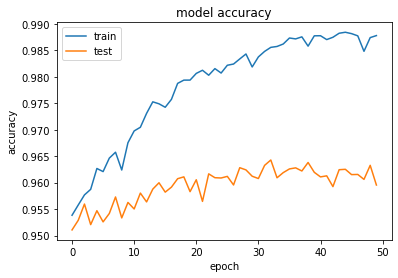

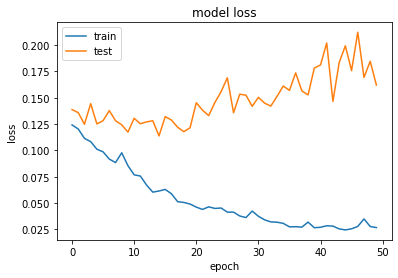

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [23]:
score = model.evaluate(x_val, y_val, verbose = 0) 
print('Test loss:', score[0]) 
print('Test MSE:',score[1])
print('Test accuracy:', score[2])

Test loss: 0.16206438839435577
Test MSE: 0.0321248359978199
Test accuracy: 0.9595403671264648


In [34]:
preds_val = model.predict(x_val, verbose=1)

5/5 [==============================] - 0s 23ms/step


In [35]:
preds_val_t = (preds_val > 0.5).astype(np.uint8)

In [39]:
def plot_sample(X, y, preds, binary_preds, ix=None):
    if ix is None:
        ix = random.randint(0, len(X))

    has_mask = y[ix].max() > 0

    fig, ax = plt.subplots(1, 4, figsize=(20, 10))
    ax[0].imshow(X[ix, ..., 0], cmap='seismic')
    if has_mask:
        ax[0].contour(y[ix].squeeze(), colors='k', levels=[0.5])
    ax[0].set_title('Cancerous')

    ax[1].imshow(y[ix].squeeze())
    ax[1].set_title('Original mask')

    ax[2].imshow(preds[ix].squeeze(), vmin=0, vmax=1)
    if has_mask:
        ax[2].contour(y[ix].squeeze(), colors='k', levels=[0.5])
    ax[2].set_title('MAsk Predicted')
    
    ax[3].imshow(binary_preds[ix].squeeze(), vmin=0, vmax=1)
    if has_mask:
        ax[3].contour(y[ix].squeeze(), colors='k', levels=[0.5])
    ax[3].set_title('Cancer Predicted binary');

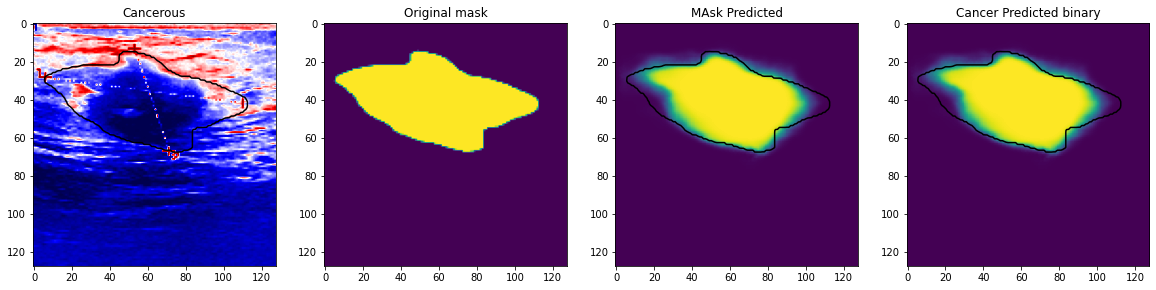

In [40]:
plot_sample(x_val, y_val, preds_val, preds_val)

In [33]:
!zip -r file.zip /kaggle/input/breast-ultrasound-images-dataset

  adding: kaggle/input/breast-ultrasound-images-dataset/ (stored 0%)
  adding: kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/ (stored 0%)
  adding: kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/ (stored 0%)
  adding: kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (2).png (deflated 23%)
  adding: kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (285).png (deflated 22%)
  adding: kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (166)_mask.png (deflated 4%)
  adding: kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (290)_mask.png (stored 0%)
  adding: kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (300).png (deflated 21%)
  adding: kaggle/input/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign/benign (390).png (deflated 24%)
  adding: kaggle/input/breast-ultrasound-ima